In [9]:
import sys
!{sys.executable} -m pip install -U seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [10]:
import sys
!{sys.executable} -m pip install -U plotnine

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [11]:
import sys
!{sys.executable} -m pip install -U pandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [12]:
import pandas as pd
import plotnine as p9
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [15]:
# Reading .csv files from reorganized raw data folders
t06 = pd.read_csv("raw data/tenure by year/2006.csv")
t07 = pd.read_csv("raw data/tenure by year/2007.csv")
t09 = pd.read_csv("raw data/tenure by year/2009.csv")
t10 = pd.read_csv("raw data/tenure by year/2010.csv")
t11 = pd.read_csv("raw data/tenure by year/2011.csv")
t12 = pd.read_csv("raw data/tenure by year/2012.csv")
t13 = pd.read_csv("raw data/tenure by year/2013.csv")
t14 = pd.read_csv("raw data/tenure by year/2014.csv")
t15 = pd.read_csv("raw data/tenure by year/2015.csv")
t16 = pd.read_csv("raw data/tenure by year/2016.csv")
t17 = pd.read_csv("raw data/tenure by year/2017.csv")
t18 = pd.read_csv("raw data/tenure by year/2018.csv")
t19 = pd.read_csv("raw data/tenure by year/2019.csv")
t20 = pd.read_csv("raw data/tenure by year/2020.csv")
h_recycle = pd.read_csv("raw data/household-recycling-borough.csv")
income = pd.read_csv("raw data/income-of-tax-payers-borough.csv")
house_prices = pd.read_csv("raw data/house-prices-borough.csv")




In [18]:
# Optional: robust house-prices cleaning
# Supports both long format (with "Area" column) and wide format (areas as columns).
house_prices_clean = house_prices.dropna().copy()

areas_to_exclude = {
    "City of London",
    "North East",
    "North West",
    "Yorkshire and The Humber",
    "Yorkshire And The Humber",
    "East Midlands",
    "West Midlands",
    "East of England",
    "South East",
    "South West",
    "England",
    "Wales",
    "Scotland",
    "Northern Ireland",
    "United Kingdom",
    "London",
    "England And Wales",
}

if "Area" in house_prices_clean.columns:
    house_prices_clean = house_prices_clean[
        ~house_prices_clean["Area"].astype(str).str.strip().isin(areas_to_exclude)
    ]


In [17]:
#checking the format
t07.head()

,Borough,Own Outright,Buying with mortgage
0,Barking and Dagenham,21.5,34.3
1,Barnet,30.1,36.8
2,Bexley,32.6,45.3
3,Brent,23.9,30.2
4,Bromley,31.6,42.9


In [19]:
#making a list of the all the dataframes to concat them all together
df_list= []
df_list.append(t06)
df_list.append(t07)
df_list.append(t09)
df_list.append(t10)
df_list.append(t11)
df_list.append(t12)
df_list.append(t13)
df_list.append(t14)
df_list.append(t15)
df_list.append(t16)
df_list.append(t17)
df_list.append(t18)
df_list.append(t19)
df_list.append(t20)

#add a year column to tenure df's 
count = 0
for i in df_list:
    count = count + 1
    if count == 1:
        i["Year"] = 2006
    elif count ==2:
        i["Year"] = 2007
    else:
        i["Year"] = 2006 + count


for i in df_list:
    #renaming "Borough" column to "Area"
    i.rename(columns={"Borough":"Area"}, inplace=True)

    #getting rid of "inner london", "outer london" and "london" rows
    i.drop([32,33,34], axis=0, inplace=True)   

#concatanating tenure dataframes
tenure = pd.concat(df_list, ignore_index=True)

tenure.head()


,Area,Own Outright,Buying with mortgage,Year
0,Barking and Dagenham,21.6,32.4,2006
1,Barnet,27.7,35.0,2006
2,Bexley,28.5,47.2,2006
3,Brent,21.3,32.3,2006
4,Bromley,34.0,40.6,2006


In [20]:
# FIXED: ORGANIZE INCOME DATAFRAME (avoids 'Area' as both index and column)

#cleaning rows
income = income.dropna()
exclude_areas = ["City of London"
                 , "North East"
                 , "North West"
                 , "Yorkshire and The Humber"
                 , "East Midlands"
                 , "West Midlands"
                 , "East of England"
                 , "South East"
                 , "South West"
                 , "England"
                 , "Wales"
                 , "Scotland"
                 , "Northern Ireland"
                 , "United Kingdom"
                 , "London"
                 ]
income = income[~income["Area"].isin(exclude_areas)].reset_index(drop=True)

#making the years integers
income["Year"] = income["Year"].astype("int")

#dropping "Number of individuals" column (if present)
income.drop(["Number of Individuals"], axis=1, inplace=True, errors="ignore")

#renaming the Mean and Median to get rid of GBP symbol
income.rename(columns={"Mean £":"Mean","Median £":"Median"},inplace=True)

#replacing "-" with " "
income["Area"] = income["Area"].str.replace("-", " ", regex=True)

income.head()

,Year,Area,Mean,Median
0,2006,Barking and Dagenham,"20,600","17,600"
1,2006,Barnet,"36,700","20,400"
2,2006,Bexley,"24,600","19,600"
3,2006,Brent,"24,600","18,200"
4,2006,Bromley,"32,800","23,000"


In [21]:
#checking h_recycle
h_recycle.head()

,New Code,Code,Area,"1998/991,2","1999/001,2","2000/011,2","2001/021,2",2002/031,2003/041,2004/05,...,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,2020/21,2021/22,2022/23,2023/24
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E09000001,00AA,City of London,0.0,0,0.0,0.0,1.0,8.0,14.0,...,34.0,31.0,29.0,29.0,30.0,29.0,30.0,32.0,30.0,27.0
2,E09000002,00AB,Barking and Dagenham,3.0,3,4.0,3.0,3.0,5.0,14.0,...,23.0,19.0,25.0,25.0,24.0,25.0,27.0,31.0,33.0,33.0
3,E09000003,00AC,Barnet,9.0,8,8.0,8.0,13.0,16.0,20.0,...,38.0,37.0,37.0,37.0,35.0,32.0,29.0,30.0,27.0,29.0
4,E09000004,00AD,Bexley,20.0,18,17.0,20.0,23.0,21.0,30.0,...,54.0,52.0,53.0,52.0,54.0,54.0,50.0,43.0,44.0,46.0


In [22]:
#RUN THIS CELL TO ORGANIZE HOUSEHOLD RECYCLING DATAFRAME

#dropping blanks
hr=h_recycle.dropna().reset_index(drop=True)

#dropping columns in hr df (Area code, Code, years < 2006 and > 2020)
cols_hr = [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 13, 26, 27, 28]
hr.drop(hr.columns[cols_hr], axis=1, inplace=True)

#dropping rows in hr df (NaN's and locations that we are not interested in)
rows_hr = [0, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]
hr.drop(hr.index[rows_hr], inplace=True)

#changing the column names for better merge
hr.columns = ["Area", "2006", "2007", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020"]

#making a column for years and a new column for RR/HH (recycling rate per household)
hr = hr.melt(
    id_vars=["Area"]
    ,var_name="Year"
    ,value_name="RR/HH"
)
hr = hr[["Year", "Area", "RR/HH"]]

#making years integers
hr["Year"] = hr.Year.astype("int")

#resetting index
hr = hr.reset_index(drop=True)

hr.head()

,Year,Area,RR/HH
0,2006,Barking and Dagenham,21.0
1,2006,Barnet,29.0
2,2006,Bexley,40.0
3,2006,Brent,22.0
4,2006,Bromley,32.0


In [23]:
#checking format for income df
income

,Year,Area,Mean,Median
0,2006,Barking and Dagenham,"20,600","17,600"
1,2006,Barnet,"36,700","20,400"
2,2006,Bexley,"24,600","19,600"
3,2006,Brent,"24,600","18,200"
4,2006,Bromley,"32,800","23,000"
...,...,...,...,...
443,2020,Sutton,"41,400","31,400"
444,2020,Tower Hamlets,"52,700","34,100"
445,2020,Waltham Forest,"37,100","28,900"
446,2020,Wandsworth,"75,300","39,000"


In [27]:
#RUN THIS CELL TO ORGANIZE INCOME DATAFRAME

#cleaning rows
income = income.dropna()
exclude_areas = ["City of London"
                 , "North East"
                 , "North West"
                 , "Yorkshire and The Humber"
                 , "East Midlands"
                 , "West Midlands"
                 , "East of England"
                 , "South East"
                 , "South West"
                 , "England"
                 , "Wales"
                 , "Scotland"
                 , "Northern Ireland"
                 , "United Kingdom"
                 , "London"
                 ]
income = income[~income["Area"].isin(exclude_areas)].reset_index(drop=True)

#making the years integers
income["Year"] = income["Year"].astype("int")

#dropping "Number of individuals" column (if present)
income.drop(["Number of Individuals"], axis=1, inplace=True, errors="ignore")

#renaming the Mean and Median to get rid of GBP symbol
income.rename(columns={"Mean £":"Mean","Median £":"Median"},inplace=True)

#replacing "-" with " "
income["Area"] = income["Area"].str.replace("-", " ", regex=True)

income.head()

,Year,Area,Mean,Median
0,2006,Barking and Dagenham,"20,600","17,600"
1,2006,Barnet,"36,700","20,400"
2,2006,Bexley,"24,600","19,600"
3,2006,Brent,"24,600","18,200"
4,2006,Bromley,"32,800","23,000"


In [28]:
#making the final dataframe, include house prices, and check integrity
if 'house_prices' not in globals():
    # Fallback to CSV in reorganized raw data folder
    house_prices = pd.read_csv("raw data/house-prices-borough.csv")

# Handle either long format (Area/Period/Mean_Price/Median_Price)
# or wide format (Year + one column per Area)
if {"Area", "Period", "Mean_Price"}.issubset(house_prices.columns):
    house_price_clean = house_prices.copy()
    house_price_clean["Year"] = house_price_clean["Period"].astype(str).str.extract(r"(\d{4})").astype(int)
    house_price_clean["Mean_Price"] = pd.to_numeric(house_price_clean["Mean_Price"], errors="coerce")
    if "Median_Price" in house_price_clean.columns:
        house_price_clean["Median_Price"] = pd.to_numeric(house_price_clean["Median_Price"], errors="coerce")
    else:
        house_price_clean["Median_Price"] = np.nan
else:
    # Convert wide CSV (monthly, one column per area) to long annual format
    house_price_clean = house_prices.copy()
    house_price_clean["Year"] = pd.to_datetime(house_price_clean["Year"], format="%b-%y", errors="coerce").dt.year
    house_price_clean = house_price_clean.melt(id_vars=["Year"], var_name="Area", value_name="Mean_Price")
    house_price_clean["Area"] = house_price_clean["Area"].str.replace("&", "and", regex=False)
    house_price_clean["Mean_Price"] = pd.to_numeric(
        house_price_clean["Mean_Price"].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )
    house_price_clean["Median_Price"] = np.nan

house_price_clean = house_price_clean[(house_price_clean["Year"] >= 2006) & (house_price_clean["Year"] <= 2020)]
house_price_clean = house_price_clean[house_price_clean["Area"].isin(income["Area"].unique())]
house_price_annual = house_price_clean.groupby(["Year", "Area"], as_index=False)[["Mean_Price", "Median_Price"]].mean()

hr_income = pd.merge(income, hr, on=["Year", "Area"], how="inner")
final = pd.merge(hr_income, tenure, on=["Year", "Area"], how="inner")
final = pd.merge(final, house_price_annual, on=["Year", "Area"], how="left")

#getting rid of commas and spaces
final["Mean"] = final["Mean"].str.replace(",", "", regex=True)
final["Median"] = final["Median"].str.replace(",", "", regex=True)

#renaming columns for easier use in rec_plot()
final.rename(columns={"RR/HH": "HHRR", "Own Outright": "Own", "Buying with mortgage": "Mortgage", "Mean_Price": "House_Mean", "Median_Price": "House_Median"}, inplace=True)

#changing dtypes of values per column
final["Mean"] = final["Mean"].astype("float").astype("int")
final["Median"] = final["Median"].astype("float").astype("int")
final["House_Mean"] = final["House_Mean"].round(0).astype("Int64")
final["House_Median"] = final["House_Median"].round(0).astype("Int64")
final["HHRR"] = final["HHRR"].astype("float")
final["Own"] = final["Own"].astype("float")
final["Mortgage"] = final["Mortgage"].astype("float")
final["Year"] = final["Year"].astype("int")

#checking integrity
print("We are looking at 14 years of data and we have 32 areas, therefore we should have", 14*32, "rows.")
print("The final dataframe has", len(final), "rows and", len(final.columns), "columns.")
print("Values check (rows x columns):", len(final)*len(final.columns))
print("Missing values per column:")
print(final.isna().sum())
final.head()


We are looking at 14 years of data and we have 32 areas, therefore we should have 448 rows.
The final dataframe has 448 rows and 9 columns.
Values check (rows x columns): 4032
Missing values per column:
Year              0
Area              0
Mean              0
Median            0
HHRR              0
Own               0
Mortgage          0
House_Mean        0
House_Median    448
dtype: int64


,Year,Area,Mean,Median,HHRR,Own,Mortgage,House_Mean,House_Median
0,2006,Barking and Dagenham,20600,17600,21.0,21.6,32.4,172541,<NA>
1,2006,Barnet,36700,20400,29.0,27.7,35.0,309024,<NA>
2,2006,Bexley,24600,19600,40.0,28.5,47.2,191826,<NA>
3,2006,Brent,24600,18200,22.0,21.3,32.3,273046,<NA>
4,2006,Bromley,32800,23000,32.0,34.0,40.6,254004,<NA>


## Coding stops here
So run all the cells above this one for the testing to work.
## Testing starts here
You can make as many cells as you want to test.

Don't change the coding above unless you receive an error.

                            OLS Regression Results                            
Dep. Variable:                   HHRR   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     288.6
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.81e-50
Time:                        15:12:22   Log-Likelihood:                -1515.1
No. Observations:                 448   AIC:                             3034.
Df Residuals:                     446   BIC:                             3042.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.2693      1.058     14.434      0.0

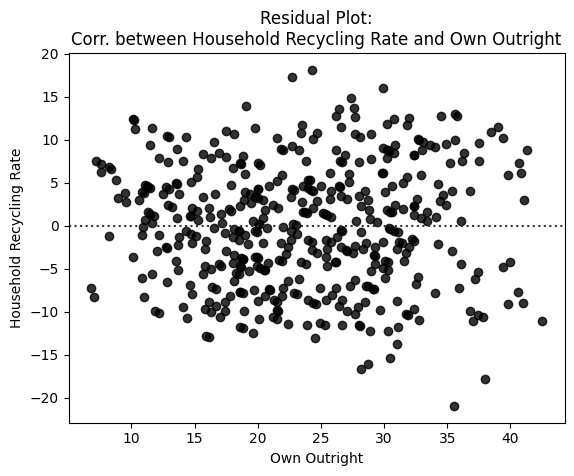

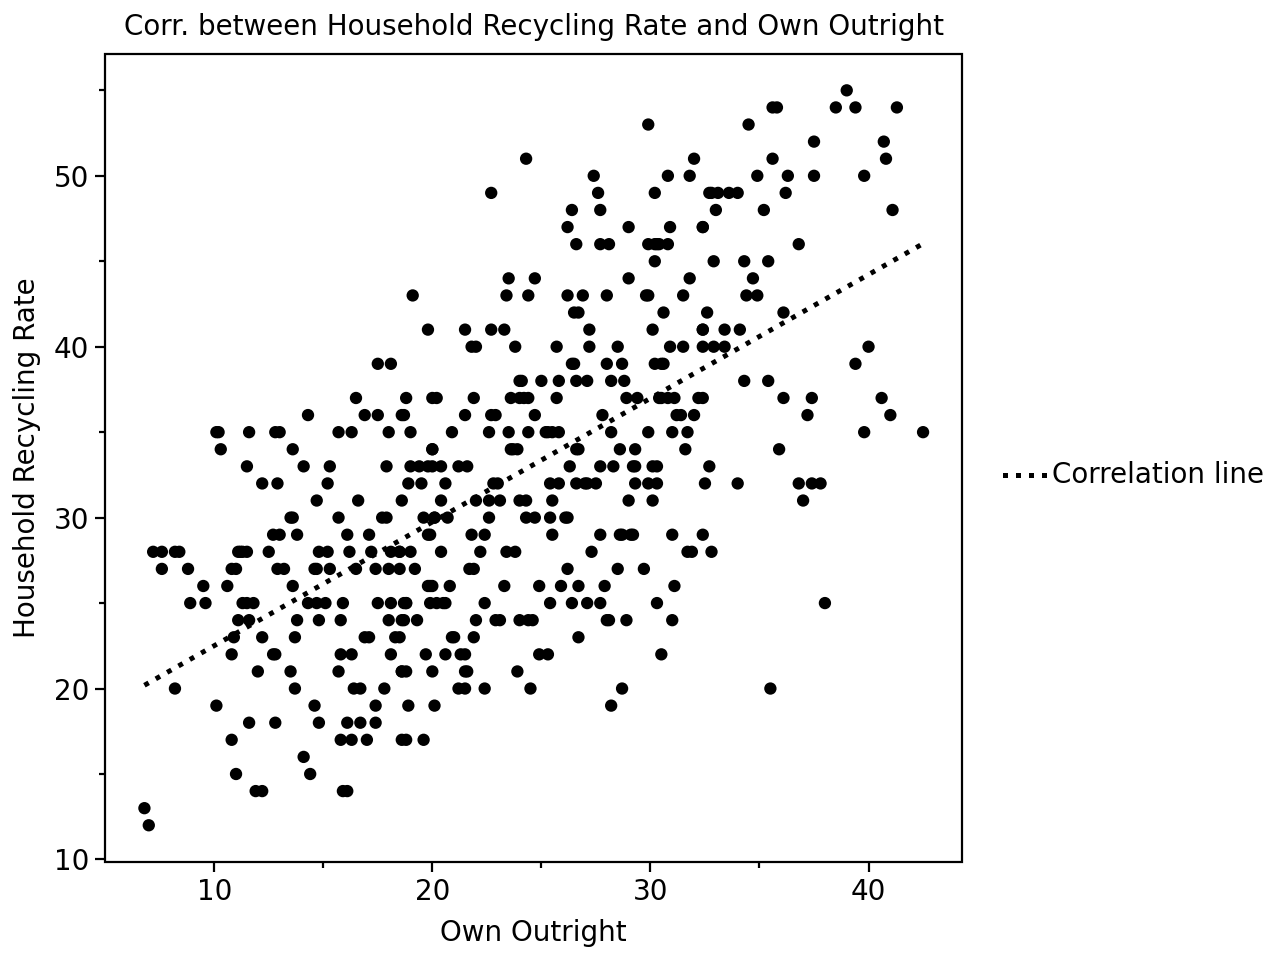

In [30]:
rec(final, "HHRR", "Own")

                            OLS Regression Results                            
Dep. Variable:                   HHRR   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.704
Date:                Tue, 31 Mar 2026   Prob (F-statistic):              0.192
Time:                        15:12:28   Log-Likelihood:                -1626.1
No. Observations:                 448   AIC:                             3256.
Df Residuals:                     446   BIC:                             3264.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.3810      2.280     12.885      0.0

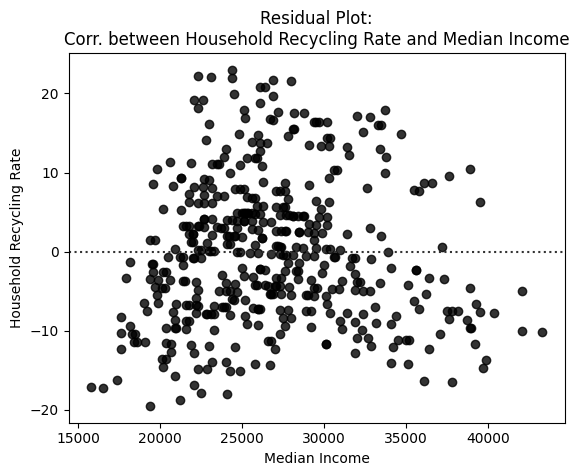

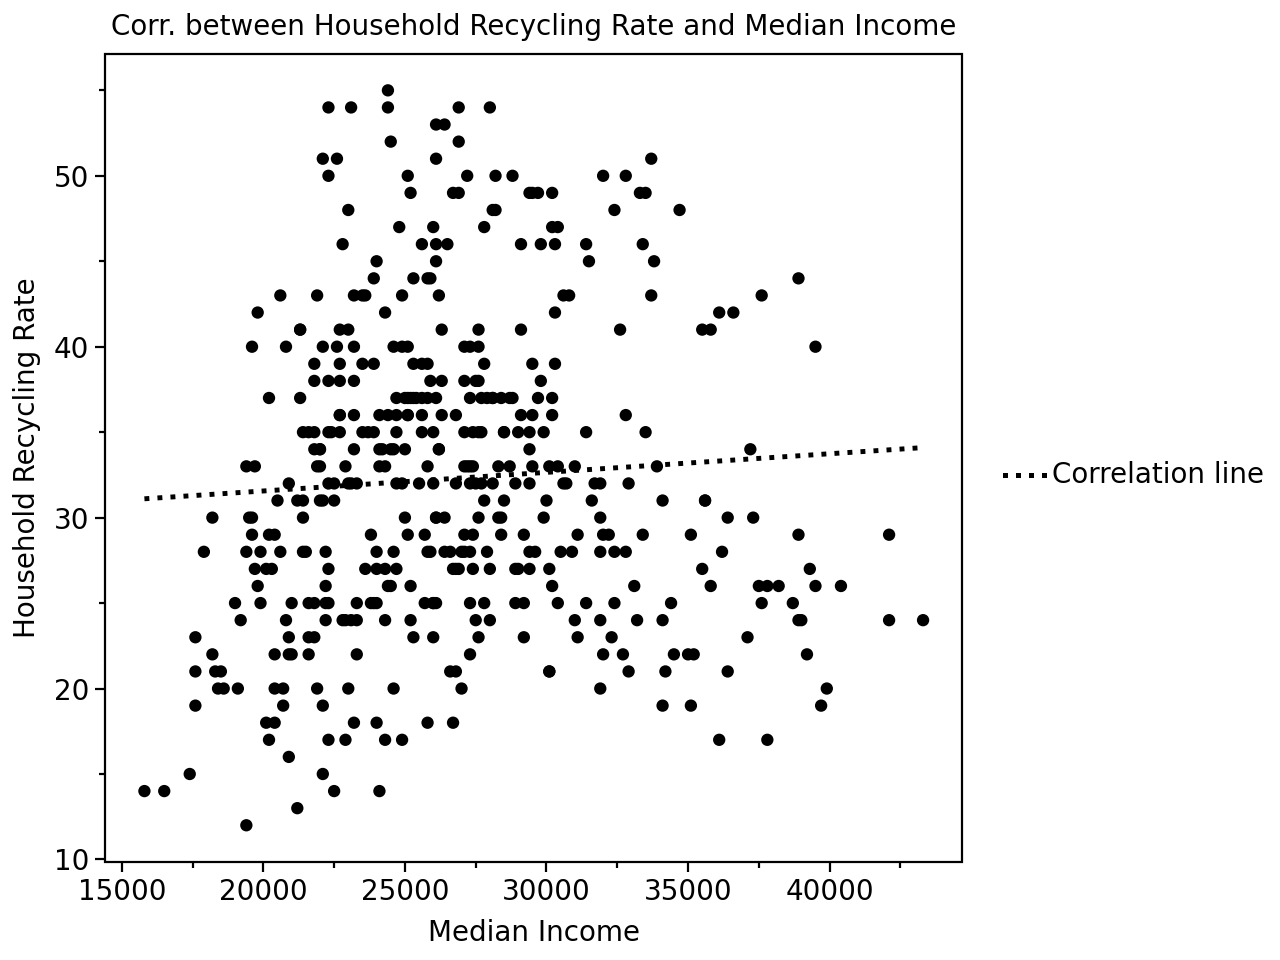

In [31]:
rec(final, "HHRR", "Median")

                            OLS Regression Results                            
Dep. Variable:                   HHRR   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     11.03
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           0.000968
Time:                        15:12:33   Log-Likelihood:                -1621.5
No. Observations:                 448   AIC:                             3247.
Df Residuals:                     446   BIC:                             3255.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.7376      0.848     40.947      0.0

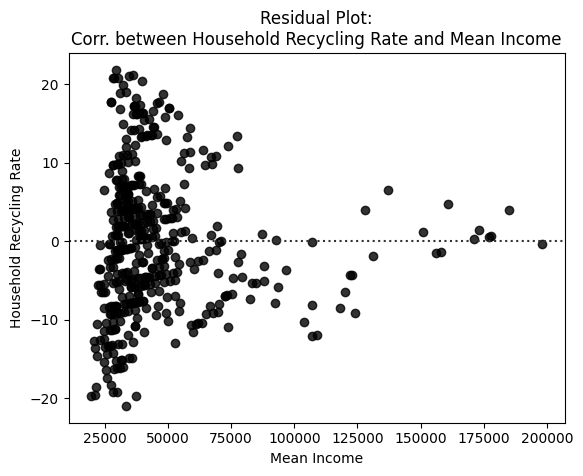

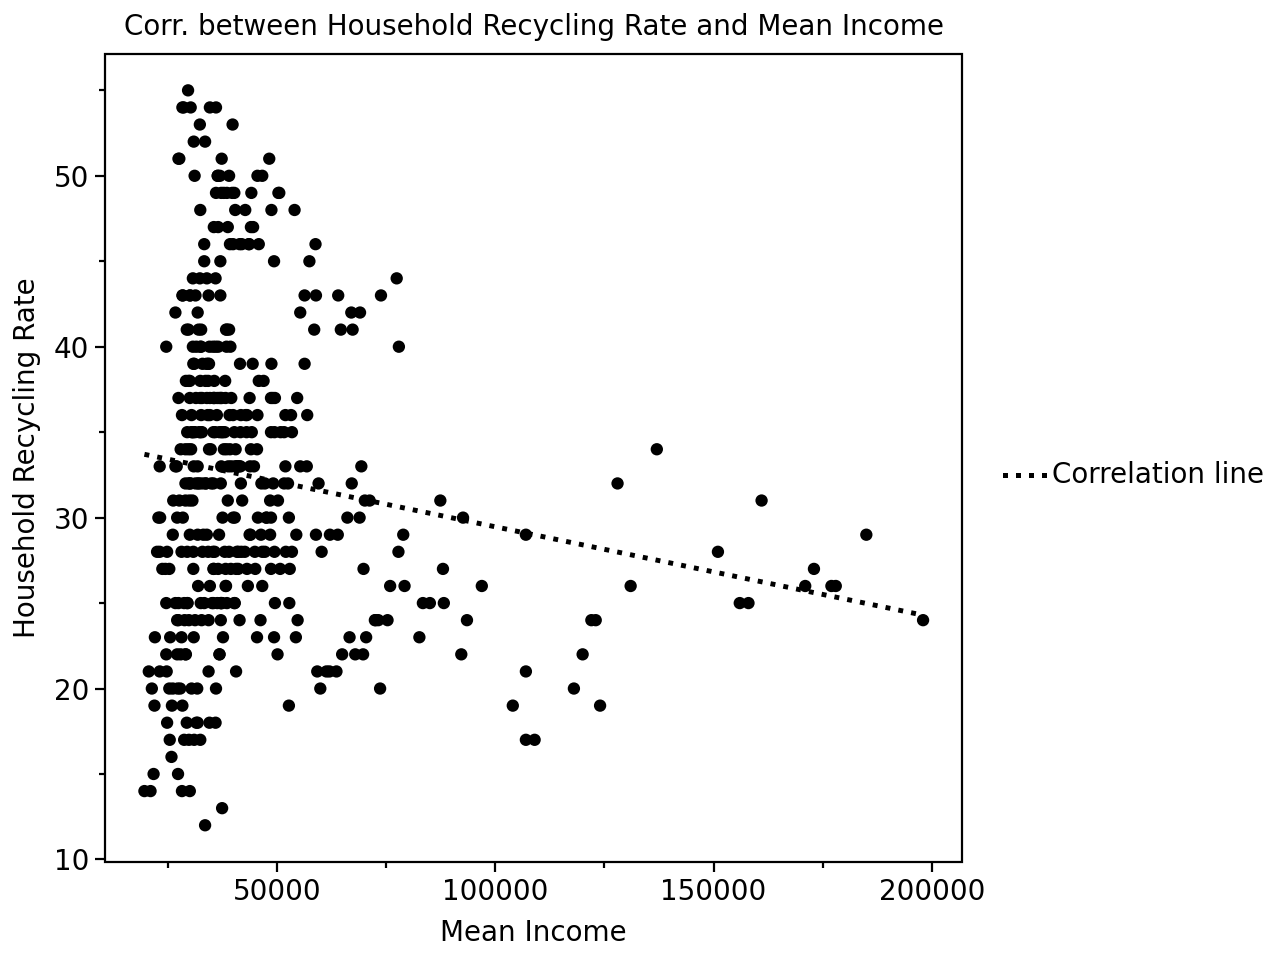

In [32]:
rec(final, "HHRR", "Mean")

In [35]:
rec(final, "House_Mean", "Own")

                            OLS Regression Results                            
Dep. Variable:             House_Mean   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.071
Date:                Tue, 31 Mar 2026   Prob (F-statistic):              0.301
Time:                        15:23:49   Log-Likelihood:                -6140.1
No. Observations:                 448   AIC:                         1.228e+04
Df Residuals:                     446   BIC:                         1.229e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.646e+05   3.22e+04     14.426      0.0

UnboundLocalError: local variable 'dv_lab' referenced before assignment